In [2]:
!pip install tensorflow

In [4]:
import math
import numpy as np
import h5py
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.python.framework import ops
from tf_utils import load_dataset, random_mini_batches, convert_to_one_hot, predict

%matplotlib inline
np.random.seed(1)

In [6]:
tf.__version__

'2.21.0'

## Compute loss for a single training example

In [10]:
y_hat = tf.constant(36, name='y_hat')            # Define y_hat constant. Set to 36.
y = tf.constant(39, name='y')                    # Define y. Set to 39

loss = tf.Variable((y - y_hat)**2, name='loss')  # Create a variable for the loss

print(loss.numpy())

9


In [11]:
c = tf.multiply(y, y_hat)
print(c)

tf.Tensor(1404, shape=(), dtype=int32)


In [13]:
print(c.numpy())

1404


In [15]:
X = tf.constant(np.random.randn(3, 1), dtype=tf.float32)
print(X.numpy())

[[-1.0729686 ]
 [ 0.86540765]
 [-2.3015387 ]]


In [16]:
def linear_function():
    np.random.seed(1)

    # Create tensors
    X = tf.constant(np.random.randn(3,1), dtype=tf.float32)
    W = tf.constant(np.random.randn(4, 3), dtype=tf.float32)
    b = tf.constant(np.random.randn(4, 1), dtype=tf.float32)

    result = tf.matmul(W, X) + b
    return result

In [18]:
# Test
result = linear_function()
print(result.numpy())   # Convert to NumPy array if needed

[[-2.1565738]
 [ 2.9589148]
 [-1.0892676]
 [-0.8453805]]


## Sigmoid function operation

In [19]:
def sigmoid(z):
    """
    Arguments:
        z: scalar, list, Numpy, Array or Tensor
    Returns:
        sigmoid od z
    """

    x = tf.convert_to_tensor(z, dtype=tf.float32)
    result = tf.sigmoid(x)

    return result

In [23]:
print(sigmoid(0.0).numpy())
print(sigmoid(10).numpy())

0.5
0.9999546


## Implementing the cost

In [ ]:
def cost(logits, labels):
    """
    Computes the sigmoid cross-entropy loss

    Arguments:
        logits: output of the last linera unit(before sigmoid)
        labels: true labels (0 or 1)

    Returns:
        loss: sigmoid cross-entropy loss
    """

    logits = tf.convert_to_tensor(logits, dtype=tf.float32)
    labels = tf.convert_to_tensor(labels, dtype=tf.float32)

    # scalar loss
    loss = tf.reduce_mean(
        tf.nn.sigmoid_cross_entropy_with_logits(
            logits=logits,
            labels=labels
        )
    )

    return loss

In [27]:
logits = [0.2, 0.8, -1.5]
labels = [0, 1, 1]

loss = cost(logits, labels)

print(loss.numpy())

0.9568842


## One-hot encoding

In [30]:
def one_hot_matrix(labels, C):
    """
    Creates a matrix where the i-th row corresponds to the ith class number and
    the jth column to the jth training example. So if example j had a label i.
    Then entry (i,j) will be 1.

    Arguments:
        labels: vector containing the labels
        C: number of classes, the depth of one-hot dimension.

    Returns:
        one-hot matrix
    """

    C = tf.constant(C, name='C')

    one_hot_matrix = tf.one_hot(labels, depth=C, axis=0)

    return one_hot_matrix


In [31]:
labels = np.array([1,2,3,0,2,1])
one_hot = one_hot_matrix(labels, C = 4)
print ("one_hot = \n" + str(one_hot))

one_hot = 
tf.Tensor(
[[0. 0. 0. 1. 0. 0.]
 [1. 0. 0. 0. 0. 1.]
 [0. 1. 0. 0. 1. 0.]
 [0. 0. 1. 0. 0. 0.]], shape=(4, 6), dtype=float32)


In [6]:
ones = tf.ones([3])
print(ones)

ones_matrix = tf.ones([3,2])
print(ones_matrix)

zeros_matrix = tf.zeros([3])
print(zeros_matrix)

tf.Tensor([1. 1. 1.], shape=(3,), dtype=float32)
tf.Tensor(
[[1. 1.]
 [1. 1.]
 [1. 1.]], shape=(3, 2), dtype=float32)
tf.Tensor([0. 0. 0.], shape=(3,), dtype=float32)


## SIGNS Dataset

In [ ]:
def load_dataset():
    train_dataset = h5py.File('/datasets/train_signs.h5', "r")
    train_set_x_orig = np.array(train_dataset["train_set_x"][:]) # your train set features
    train_set_y_orig = np.array(train_dataset["train_set_y"][:]) # your train set labels

    test_dataset = h5py.File('/datasets/test_signs.h5', "r")
    test_set_x_orig = np.array(test_dataset["test_set_x"][:]) # your test set features
    test_set_y_orig = np.array(test_dataset["test_set_y"][:]) # your test set labels

    classes = np.array(test_dataset["list_classes"][:]) # the list of classes

    train_set_y_orig = train_set_y_orig.reshape((1, train_set_y_orig.shape[0]))
    test_set_y_orig = test_set_y_orig.reshape((1, test_set_y_orig.shape[0]))

    return train_set_x_orig, train_set_y_orig, test_set_x_orig, test_set_y_orig, classes

In [16]:
# Loading the dataset
X_train_orig, Y_train_orig, X_test_orig, Y_test_orig, classes = load_dataset()

In [20]:
import os

file_size_train = os.path.getsize('/content/train_signs.h5')
file_size_test = os.path.getsize('/content/test_signs.h5')

print(f"Size of train_signs.h5: {file_size_train} bytes")
print(f"Size of test_signs.h5: {file_size_test} bytes")

print("Shape of training data: ", X_train_orig.shape)

Size of train_signs.h5: 13281872 bytes
Size of test_signs.h5: 1477712 bytes
Size of training data:  (1080, 64, 64, 3)


y = 5


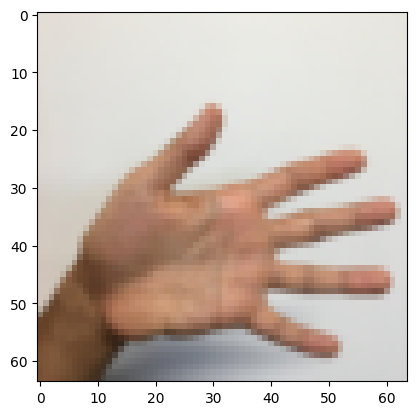

In [18]:
# Example of a picture
index = 0
plt.imshow(X_train_orig[index])
print ("y = " + str(np.squeeze(Y_train_orig[:, index])))

In [19]:
# Flatten the training and test images
X_train_flatten = X_train_orig.reshape(X_train_orig.shape[0], -1).T
X_test_flatten = X_test_orig.reshape(X_test_orig.shape[0], -1).T
# Normalize image vectors
X_train = X_train_flatten/255.
X_test = X_test_flatten/255.
# Convert training and test labels to one hot matrices
Y_train = convert_to_one_hot(Y_train_orig, 6)
Y_test = convert_to_one_hot(Y_test_orig, 6)

print ("number of training examples = " + str(X_train.shape[1]))
print ("number of test examples = " + str(X_test.shape[1]))
print ("X_train shape: " + str(X_train.shape))
print ("Y_train shape: " + str(Y_train.shape))
print ("X_test shape: " + str(X_test.shape))
print ("Y_test shape: " + str(Y_test.shape))

number of training examples = 1080
number of test examples = 120
X_train shape: (12288, 1080)
Y_train shape: (6, 1080)
X_test shape: (12288, 120)
Y_test shape: (6, 120)


## Create TensorSpecs

In [24]:
import tensorflow as tf

def create_placeholders(n_x, n_y):
    """
    Creates TensorSpecs representing the expected inputs.

    Arguments:
    n_x -- number of input features
    n_y -- number of output classes

    Returns:
    X_spec -- TensorSpec for inputs
    Y_spec -- TensorSpec for labels
    """

    X_spec = tf.TensorSpec(shape=(None, n_x), dtype=tf.float32, name="X")
    Y_spec = tf.TensorSpec(shape=(None, n_y), dtype=tf.float32, name="Y")

    return X_spec, Y_spec

In [25]:
X, Y = create_placeholders(12288, 6)
print ("X = " + str(X))
print ("Y = " + str(Y))

X = TensorSpec(shape=(None, 12288), dtype=tf.float32, name='X')
Y = TensorSpec(shape=(None, 6), dtype=tf.float32, name='Y')


## Initialize parameters

In [42]:
def initialize_parameters():
    initializer = tf.keras.initializers.GlorotUniform(seed=1)

    parameters = {
        "W1": tf.Variable(initializer((12288, 25))),
        "b1": tf.Variable(tf.zeros((25,))),
        "W2": tf.Variable(initializer((25, 12))),
        "b2": tf.Variable(tf.zeros((12,))),
        "W3": tf.Variable(initializer((12, 6))),
        "b3": tf.Variable(tf.zeros((6,)))
    }

    return parameters

In [56]:
parameters = initialize_parameters()

print("W1 =", parameters["W1"].shape)
print("b1 =", parameters["b1"].shape)
print("W2 =", parameters["W2"].shape)
print("b2 =", parameters["b2"].shape)

W1 = (12288, 25)
b1 = (25,)
W2 = (25, 12)
b2 = (12,)


In [58]:
def forward_propagation(X, parameters):

    W1 = parameters["W1"]
    b1 = parameters["b1"]
    W2 = parameters["W2"]
    b2 = parameters["b2"]
    W3 = parameters["W3"]
    b3 = parameters["b3"]

    Z1 = tf.matmul(X, W1) + b1
    A1 = tf.nn.relu(Z1)

    Z2 = tf.matmul(A1, W2) + b2
    A2 = tf.nn.relu(Z2)

    Z3 = tf.matmul(A2, W3) + b3

    return Z3

In [59]:
# Create a dummy batch of 5 images
X = tf.random.normal(shape=(5, 12288))

parameters = initialize_parameters()

Z3 = forward_propagation(X, parameters)

print("Z3 shape:", Z3.shape)
print(Z3)

Z3 shape: (5, 6)
tf.Tensor(
[[-0.4169296  -0.29181942 -0.15837118 -0.28853354 -0.28987914 -0.09364519]
 [ 0.32762203  0.70194125 -0.28147393  1.0352087   0.0234597   0.84628963]
 [ 0.1853069  -0.2819259   0.27236125 -0.31740347 -0.42449108 -0.19310004]
 [-1.1829822   0.13486463  0.5253548  -0.05206828 -1.0150201  -0.05978525]
 [ 0.26091605  0.15196174  0.67964315  0.7289822  -0.7243796   0.12778741]], shape=(5, 6), dtype=float32)


In [60]:
def compute_cost(Z3, Y):
    loss = tf.nn.softmax_cross_entropy_with_logits(
        labels=Y,
        logits=Z3
    )
    return tf.reduce_mean(loss)

In [61]:
# Create dummy data (batch_size = 5)
X = tf.random.normal(shape=(5, 12288))
Y = tf.one_hot(tf.random.uniform(shape=(5,), maxval=6, dtype=tf.int32), depth=6)

# Initialize parameters
parameters = initialize_parameters()

# Forward propagation
Z3 = forward_propagation(X, parameters)

# Compute cost
cost = compute_cost(Z3, Y)

print("cost =", cost.numpy())

cost = 1.6173456


In [62]:
def compute_accuracy(Z3, Y):
    preds = tf.argmax(Z3, axis=1)
    labels = tf.argmax(Y, axis=1)
    return tf.reduce_mean(tf.cast(preds == labels, tf.float32))

In [63]:
def train_step(X, Y, parameters, optimizer):

    with tf.GradientTape() as tape:
        Z3 = forward_propagation(X, parameters)
        cost = compute_cost(Z3, Y)

    grads = tape.gradient(cost, list(parameters.values()))

    optimizer.apply_gradients(zip(grads, parameters.values()))

    return cost

In [64]:
def model(X_train, Y_train, X_test, Y_test,
          learning_rate=0.0001,
          num_epochs=1500,
          batch_size=32):

    tf.random.set_seed(1)

    parameters = initialize_parameters()
    optimizer = tf.keras.optimizers.Adam(learning_rate)

    dataset = tf.data.Dataset.from_tensor_slices((X_train, Y_train))
    dataset = dataset.shuffle(1000).batch(batch_size)

    costs = []

    for epoch in range(num_epochs):

        epoch_cost = 0

        for X_batch, Y_batch in dataset:

            cost = train_step(X_batch, Y_batch, parameters, optimizer)
            epoch_cost += cost.numpy()

        epoch_cost /= len(dataset)
        costs.append(epoch_cost)

        if epoch % 100 == 0:
            print(f"Epoch {epoch}, cost = {epoch_cost:.4f}")

    # Plot cost
    plt.plot(costs)
    plt.xlabel("Epochs")
    plt.ylabel("Cost")
    plt.title("Training Cost")
    plt.show()

    # Accuracy
    train_Z3 = forward_propagation(X_train, parameters)
    test_Z3 = forward_propagation(X_test, parameters)

    train_acc = compute_accuracy(train_Z3, Y_train)
    test_acc = compute_accuracy(test_Z3, Y_test)

    print("Train Accuracy:", train_acc.numpy())
    print("Test Accuracy:", test_acc.numpy())

    return parameters

In [ ]:
X_train = X_train.T
X_test = X_test.T
Y_train = Y_train.T
Y_test = Y_test.T

parameters = model(X_train, Y_train, X_test, Y_test)

In [66]:
X_train.shape
Y_train.shape

(1080, 6)